In [1]:
#Simulations with constant volatility

In [2]:
#import of packages

import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm #matrix square root
from scipy.stats import gaussian_kde

print("ok")

ok


In [34]:
#import monte carlo skripts and plotting functions from other notebooks

import os
print(os.listdir())

%run Monte_Carlo_functions.ipynb
%run Plot_functions.ipynb

print(skripts_work())
print(plots_work())

print("ok")

['.ipynb_checkpoints', 'constant_vola_eigenvalues_rv.png', 'constant_vola_error_boxplot.png', 'constant_vola_kde_lambda_prv_ranks_hist.png', 'Monte_Carlo_functions.ipynb', 'Plot_functions.ipynb', 'Simulation.ipynb', 'V_1']
ok
ok
ok
ok
ok
ok
Monte carlo skript functions integrated.
Plotting functions integrated.
ok


In [4]:
#testing parameters

test=0  #on = 1, off = 0

print("ok")

ok


In [5]:
#elementary functions for generation of log-price paths


#generate QV and a denoised one
def qv_generator_with_denoiser(eigenvalues, number_vanishing_eigenvalues):
    """
    Create a random qv matrix Sigma as symmetric matrix with specified eigenvalues
    and a denoised version without the smallest number_vanishing_terms terms in the SVD.

    Parameters
    ----------
    eigenvalues : array-like
        Desired eigenvalues of the matrix.
    number_vanishing_eigenvalues : int
        How many eigenvalues are negligible in the SVD.

    Returns
    -------
    Sigma : numpy.ndarray
        Sigma matrix with given eigenvalues.
    Sigma_denoised : numpy.ndarray
        Sigma matrix which neglects the smallest number_vanishing_terms terms in the SVD.
    """
    eigenvalues = np.asarray(eigenvalues)
    d = len(eigenvalues)

    A = np.random.normal(size=(d, d))
    U, S, V_T = np.linalg.svd(A)

    D = np.diag(eigenvalues)
    Sigma = U @ D @ U.T

    eigenvalues_denoised=eigenvalues.copy()
    eigenvalues_denoised[d-number_vanishing_eigenvalues:d]=np.zeros(number_vanishing_eigenvalues)
    # denoised eigenvalues are zero on vanishing positions, attention: stop: exklusive

    D_denoised=np.diag(eigenvalues_denoised)
    Sigma_denoised=U @ D_denoised @ U.T

    return Sigma , Sigma_denoised

#generate quadratic variation with special properties on eigenvalues

def special_qv_generator(d=30, dominant_eigenvalues=1, mu_dominant=22, std_dominant=1,
                         normal_eigenvalues=2, mu_normal=7, std_normal=1, mu_vanishing=0, std_vanishing=0.1):
    """
    Create a random QV matrix Sigma as symmetric matrix with randomly chosen eigenvalues following normal distributions.
    Also return a denoised version without the vanishing components in the SVD.

    Parameters
    ----------
    d : int
        Dimenions of log-prices and number of columns and rows of Sigma.
    dominant_eigenvalues : int
        Number of dominant eigenvalues, e.g., market factor???
    mu_dominant: int
        Mean of dominant eigenvalues.
    std_dominant: int
        Standard deviation of dominant eigenvalues.
    normal_eigenvalues : int
        Number of normal eigenvalues.
        The number of small eigenvalues that vanish in the limit is: d-(dominant_eigenvalues+normal_eigenvalues).
    mu_normal: int
        Mean of normal eigenvalues.
    std_normal: int
        Standard deviation of normal eigenvalues.
    mu_vanishing: int
        Mean of vanishing eigenvalues.
    std_vanishing: int
        Standard deviation of vanishing eigenvalues.

    Returns
    -------
    Sigma : numpy.ndarray
        Sigma matrix.

    Sigma_denoised : numpy.ndarray
        Sigma matrix without components from vanishing eigenvalues.

    """
    eigenvalues = np.zeros(d)

    eigenvalues[0 : dominant_eigenvalues]=np.random.normal(loc=mu_dominant, scale=std_dominant, size=dominant_eigenvalues)

    eigenvalues[dominant_eigenvalues : dominant_eigenvalues + normal_eigenvalues]=(
        np.random.normal(loc=mu_normal, scale=std_normal, size=normal_eigenvalues))

    eigenvalues[dominant_eigenvalues + normal_eigenvalues : d]=(
        np.abs(np.random.normal(loc=mu_vanishing, scale=std_vanishing, size= d-(dominant_eigenvalues+normal_eigenvalues))))

    Sigma, Sigma_denoised = qv_generator_with_denoiser(eigenvalues, d-(dominant_eigenvalues+normal_eigenvalues))
    # denoised eigenvalues have zeros outside of dominant and normal

    return Sigma , Sigma_denoised


#generate increments fast

def fast_increments_generator(volatility, drift, sampling_interval=0.01):
    """
    Create the increments of observations along a path of log-prices induced by a fixed drift and volatility
    using the Euler-Maruyama scheme. As the calculation is vectorized, it should be fast.

    Parameters
    ----------
    volatility : numpy.ndarray
        Stochastic volatility of the Itô process.
    drift : numpy.ndarray
        Stochastic drift of the Itô process.
    sampling_interval: float
        Time diffference between observations on [o,1].

    Returns
    -------
    observed_increments : numpy.ndarray
        Matrix with the increments of the log-prices on the interval [(i-1)*sampling_interval,i*sampling_interval]
        in the i-th row.

    """

    d=volatility.shape[0]
    n=int(np.floor(1/sampling_interval))

    observed_increments=np.zeros((n,d))

    dW=np.sqrt(sampling_interval)*np.random.randn(n,d)

    diffusion= (volatility@(dW.T)).T # create a n times d matrix, each row is the diffusion vector
    drift_matrix=np.tile(sampling_interval*drift, (n,1)) # create a n times d matrix, each row is the drift vector

    observed_increments=drift_matrix+diffusion

    return observed_increments


print("ok")


ok


In [6]:
#elementary functions for estimators


#fast realized variance estimator

def fast_realized_variance(observed_increments):
    """
    Calculate realized variance Sigma_hat from log-price increments. As the calculation is vectorized, it should be fast.

    Parameters
    ----------
    observed_increments : numpy.ndarray
        Matrix with the increments of the log-prices on the interval [(i-1)*sampling_interval,i*sampling_interval]
        in the i-th row.

    Returns
    -------
    Sigma_hat : numpy.ndarray
        Matrix estimator of the underlying QV.

    """

    Sigma_hat=(observed_increments.T) @ observed_increments

    return Sigma_hat



#prv estimator if RV and lambda are known

def penalized_realized_variance_for_given_lambda_and_RV(Sigma_hat, tuning_parameter_lambda):
    """
    Calculate the PRV estimator Sigma_hat_lambda from the RV estimator and the tuning parameter lambda.

    Parameters
    ----------
    Sigma_hat : numpy.ndarray
        Realized variance estimator.
    tuning_parameter_lambda : int
        The tuning parameter lambda used as prefactor of the nuclear norm penalization.

    Returns
    -------
    Sigma_hat_lambda : numpy.ndarray
        Matrix estimator of the underlying QV.
    rank_of_prv : int
        Rank of the PRV estimator matrix.

    """
    d=Sigma_hat.shape[0]
    Sigma_hat_lambda=np.zeros((d,d))
    rank_of_prv=d #if all shrinked eigenvalues are positive, the else below is never reached, so need rank d then

    #prv calculation (with Theorem 3.6 in the thesis)

    eigvals_rv_ascending, U = np.linalg.eigh(Sigma_hat)
    # rv symmetric, hence, it returns ascending eigvals and eigvecs in columns of U

    eigvals_rv=np.flip(eigvals_rv_ascending) #eigenvals now in descending order

    for z in range(d):
        if eigvals_rv[z]>(tuning_parameter_lambda/2):
            Sigma_hat_lambda+=(eigvals_rv[z]-(tuning_parameter_lambda/2))* ((U[:,d-z-1].reshape(d,1)) @ (U[:,d-z-1].reshape(d,1).T))
            #attention: since eigenvales are flipped, the index in U is d-z-1, not z!
        else:
            #as descending, all others are also smaller (lambda_final/2)
            rank_of_prv=z
            break


    return Sigma_hat_lambda, rank_of_prv


#subsampling procedure for the data-driven selection of lambda

def lambda_selection_via_subsampling_procedure(observed_increments, L_lambda=6):
    """
    Calculate the tuning parameter lambda_subsam by an subsmapling procedure following section 2.4 in Christensen et al. (2022).

    Parameters
    ----------
    observed_increments : numpy.ndarray
        Matrix with the increments of the log-prices on the interval [(i-1)*sampling_interval,i*sampling_interval]
        in the i-th row.
    L_lambda : int
        The hyperparameter L_lambda defines the number of subsamples used in the choice of the tuning parameter lambda.

    Returns
    -------
    lambda_subsam: float
        Tuning parameter that is applied for PRV.

    """
    n,d=observed_increments.shape
    sigma_hat_rv=fast_realized_variance(observed_increments)

    #subsampling for choice of lambda
    lambdas=np.zeros(L_lambda)

    for l in range(L_lambda):
        observed_increments_subsample=observed_increments[np.arange(l,n,L_lambda),:] #start, stop, step
        #l, l+L, l+2L,...,(n/L-1)*L+L
        subsample_rv=L_lambda*fast_realized_variance(observed_increments_subsample) #equation (2.24) in Christensen et al. (2022)
        lambdas[l]=(2/np.sqrt(L_lambda))*np.linalg.norm((subsample_rv - sigma_hat_rv), ord=2)
        #equation (2.25) in Christensen et al. (2022), spectral norm here order 2

    lambda_subsam=np.mean(lambdas) #equation (2.26) in Christensen et al. (2022)

    return lambda_subsam


print("ok")

ok


In [23]:
#fast analysis

#setup
d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

dominant_eigenvalues=1 #motivated by 3 factor model of Fama and French
normal_eigenvalues=2

Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, mu_dominant=10, std_dominant=0.2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5, std_normal=0.2,
                                             mu_vanishing=0.5, std_vanishing=0.2)

true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing
print("True eigenvalues of Sigma: ", true_eigenvalues_Sigma )

drift=np.random.randn(1,d)


print('ok')

True eigenvalues of Sigma:  [10.37675909  5.411857    4.9131827   0.79029034  0.77223721  0.73377156
  0.72320528  0.71555739  0.66260179  0.64595938  0.63101908  0.62506184
  0.60057494  0.57903284  0.55764048  0.54910433  0.54342178  0.51002509
  0.4998723   0.43978405  0.43910072  0.3998778   0.37388684  0.34315393
  0.33572373  0.2737067   0.26670739  0.22769635  0.1617048   0.01246852]
ok


In [24]:
number_of_simulations=10000 #10000 for factor = 5 runs in 2 min
                            #100 for factor = 300 runs in 1 min

#monte carlo simulation
eigenvalues_rv , eigenvalues_prv , lambdas_used , rank_rv , rank_prv , all_errors=fast_monte_carlo_simulation_with_fixed_QV(
    Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
    L_lambda=L_lambda, number_of_simulations=number_of_simulations, number_error_types=12,
    progress_number=number_of_simulations/10)


print('ok')

0 simulations: finished.
1000 simulations: finished.
2000 simulations: finished.
3000 simulations: finished.
4000 simulations: finished.
5000 simulations: finished.
6000 simulations: finished.
7000 simulations: finished.
8000 simulations: finished.
9000 simulations: finished.
ok


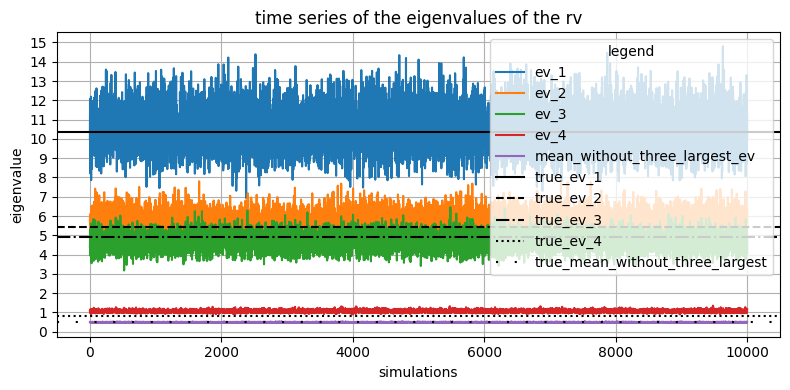

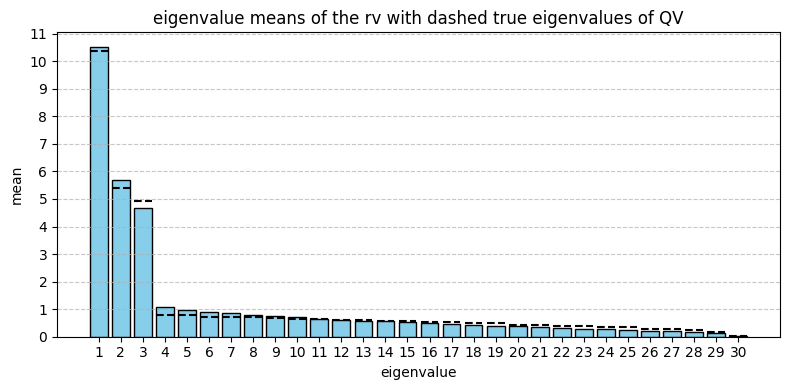

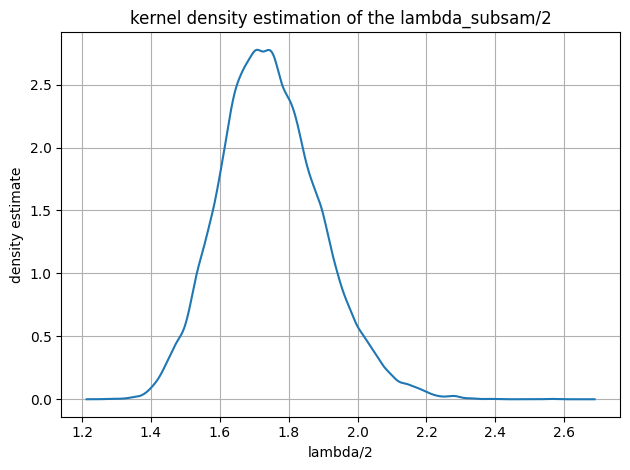

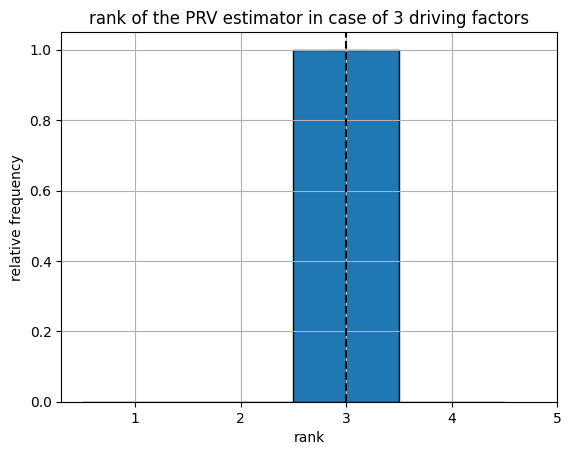

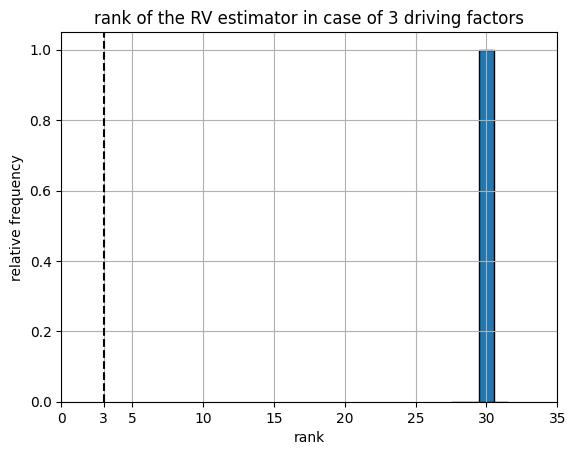

In [25]:
#plots

plot_eigenvalues_rv(eigenvalues_rv, true_eigenvalues_Sigma, title="time series of the eigenvalues of the rv", save_image=0,
                        name_of_copy="plot_eigenvalues_rv.png")
#plot_eigenvalues_rv(eigenvalues_prv, true_eigenvalues_Sigma, title="time series of the eigenvalues of the prv", save_image=0,
                        #name_of_copy="plot_eigenvalues_prv.png")
plot_means_of_eigenvalues(eigenvalues_rv, true_eigenvalues_Sigma,
                          title="eigenvalue means of the rv with dashed true eigenvalues of QV", save_image=0,
                          name_of_copy="plot_mean_eigenvalues_rv.png")
#plot_means_of_eigenvalues(eigenvalues_prv, true_eigenvalues_Sigma,
                          #title="eigenvalue means of the prv with dashed true eigenvalues of QV", save_image=0,
                          #name_of_copy="plot_mean_eigenvalues_prv.png")
kde_of_lambdas_half(lambdas_used, smoothing=0.1, title="kernel density estimation of the lambda_subsam/2", save_image=0,
                        name_of_copy="kde_of_half_of_lambda_subsam.png")
histogram_of_the_rank(rank_prv, true_rank_of_denoised_Sigma=np.linalg.matrix_rank(Sigma_denoised),
                      title="rank of the PRV estimator",
                      save_image=0, name_of_copy="histogram_rank_prv.png")
histogram_of_the_rank(rank_rv, true_rank_of_denoised_Sigma=np.linalg.matrix_rank(Sigma_denoised),
                      title="rank of the RV estimator",
                      save_image=0, name_of_copy="histogram_rank_rv.png")



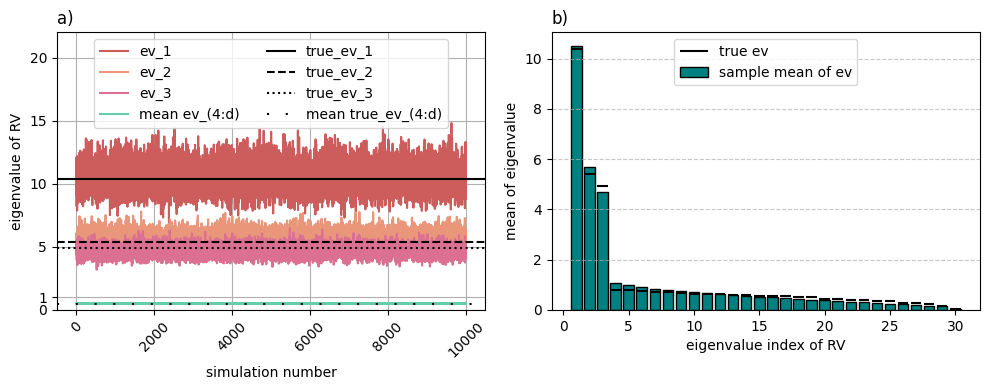

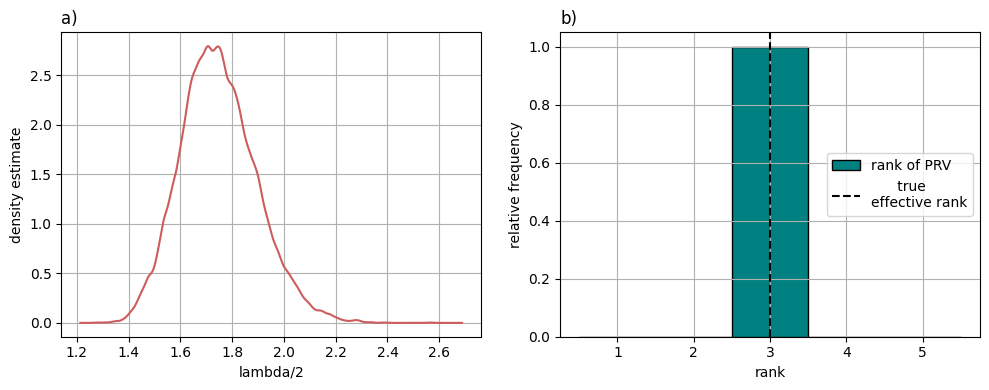

ok


In [31]:
#plot for thesis

#rv eigenvalues and their means over time


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) ev evolution
eigenvalue_mean_rv_without_three_largest=np.mean(eigenvalues_rv[:, 3:], axis=1)

ax1.plot(eigenvalues_rv[:, 0], label='ev_1', color="indianred")
ax1.plot(eigenvalues_rv[:, 1], label='ev_2', color="darksalmon")
ax1.plot(eigenvalues_rv[:, 2], label='ev_3', color="palevioletred") #darkkhaki
#ax1.plot(eigenvalues_rv[:, 3], label='ev_4', color="olive")
ax1.plot(eigenvalue_mean_rv_without_three_largest, label='mean ev_(4:d)', color="mediumaquamarine")

ax1.axhline(y=true_eigenvalues_Sigma[0], linestyle="-", label="true_ev_1", color="black")
ax1.axhline(y=true_eigenvalues_Sigma[1], linestyle="--", label="true_ev_2", color="black")
ax1.axhline(y=true_eigenvalues_Sigma[2], linestyle=":", label="true_ev_3", color="black")
#ax1.axhline(y=true_eigenvalues_Sigma[3], linestyle="-.", label="true_ev_4", color="black")
ax1.axhline(y=np.mean(true_eigenvalues_Sigma[3:]), linestyle=(0, (1, 8)), label="mean true_ev_(4:d)", color="black")


ax1.tick_params(axis='y')
ax1.set_xlabel("simulation number")
ax1.set_ylabel("eigenvalue of RV")
ax1.set_title("a) ", loc="left")
ax1.legend(ncol=2, loc="upper center")
ax1.grid(True)
ax1.tick_params(axis='x',rotation=45)
ax1.set_ylim((0,22))
ax1.set_yticks([0,1,5,10,15,20])


#b) means across the replications

# Compute mean of each column
eigenvalue_means = np.mean(eigenvalues_rv, axis=0)

cols= np.arange(1, d+1)

ax2.bar(cols, eigenvalue_means, color='teal', edgecolor='black', label="sample mean of ev") #color='mediumaquamarine'

width=0.8
for k in range(len(true_eigenvalues_Sigma)-1):
    ax2.hlines(y=true_eigenvalues_Sigma[k], xmin=cols[k]-width/2, xmax=cols[k]+width/2, colors="black", linestyle="-")
ax2.hlines(y=true_eigenvalues_Sigma[len(true_eigenvalues_Sigma)-1], xmin=cols[len(true_eigenvalues_Sigma)-1]-width/2, xmax=cols[len(true_eigenvalues_Sigma)-1]+width/2, colors="black", linestyle="-", label="true ev" )    

ax2.set_xlabel("eigenvalue index of RV")
ax2.set_ylabel("mean of eigenvalue")
ax2.tick_params(axis='y')
ax2.tick_params(axis='x')
ax2.legend(ncol=1, loc="upper center")

ax2.set_title("b)", loc="left")
ax2.grid(axis='y', linestyle='--', alpha=0.7) #only horizontal lines

plt.tight_layout()
plt.show()

fig.savefig("constant_vola_eigenvalues_rv.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()


#######################################

#plot for thesis


#kernel density estimate of tuning parameter and histogram of PRV ranks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) kde

smoothing=0.08
kde = gaussian_kde(lambdas_used/2, bw_method=smoothing) #bw_method controls smoothing
x = np.linspace(np.min(lambdas_used/2)*0.95, np.max(lambdas_used/2)*1.05, 1000)
ax1.plot(x, kde(x), color="indianred")
ax1.set_xlabel("lambda/2")
ax1.set_ylabel("density estimate")
ax1.set_title("a)", loc="left")
ax1.grid(True)


#b) histogram

#histogram of prv ranks
ranks=rank_prv
bins_def = np.arange(np.min(ranks)-2, np.max(ranks) + 4) - 0.5      #bin edges:-0.5,0.5,...,max_rank+2-0.5
ax2.hist(ranks, bins=bins_def, density=True, edgecolor='black', color='teal', label="rank of PRV")  #density for relative

true_rank_of_denoised_Sigma=np.linalg.matrix_rank(Sigma_denoised)
ax2.axvline(x=true_rank_of_denoised_Sigma,color="black",linestyle="--",linewidth=1.5, label="      true\neffective rank")
ax2.tick_params(axis='x')
ax2.set_xticks(np.arange(min(np.min(ranks) -2, true_rank_of_denoised_Sigma) ,
                        max(np.max(ranks) + 3, true_rank_of_denoised_Sigma)))


ax2.set_xlabel("rank")
ax2.set_ylabel("relative frequency")
ax2.set_title("b)", loc="left")
ax2.grid(True)
ax2.legend(ncol=1, loc="center right")

plt.tight_layout()
plt.show()

fig.savefig("constant_vola_kde_lambda_prv_ranks_hist.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()


print("ok")


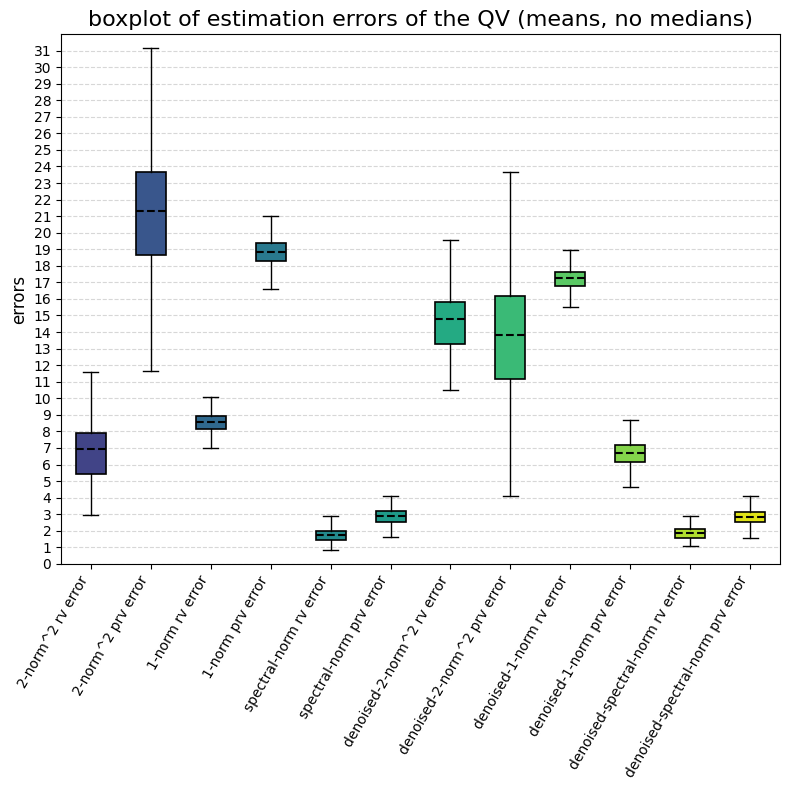

In [35]:
boxplot_estimation_errors(all_errors, title="boxplot of estimation errors of the QV (means, no medians)", save_image=0,
                              name_of_copy="boxplot_est_errors.png")

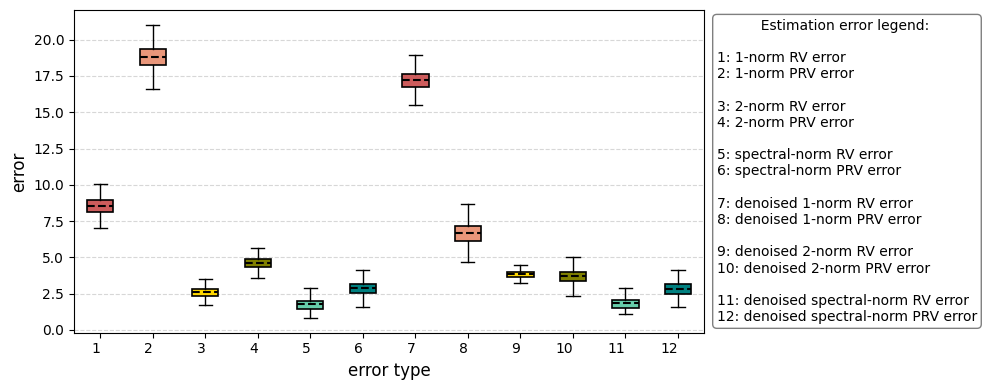

boxplot of estimation errors of the QV (means, no medians, no outliers)
ok


In [36]:
#plot for thesis

#boxplots of the errors

data=[all_errors[:,2], all_errors[:,3], np.sqrt(all_errors[:,0]), np.sqrt(all_errors[:,1]), 
      all_errors[:,4], all_errors[:,5], all_errors[:,8], all_errors[:,9],
      np.sqrt(all_errors[:,6]), np.sqrt(all_errors[:,7]),  all_errors[:,10], all_errors[:,11] ]

labels_errors=["1-norm rv error", "1-norm prv error",
        "2-norm rv error", "2-norm prv error",
        "spectral-norm rv error", "spectral-norm prv error",
        "denoised-1-norm rv error", "denoised-1-norm prv error",
        "denoised-2-norm rv error", "denoised-2-norm prv error",
        "denoised-spectral-norm rv error", "denoised-spectral-norm prv error"]
labels=range(1,13)

colors=["indianred","darksalmon","gold", "olive","mediumaquamarine", "teal",
        "indianred","darksalmon","gold", "olive","mediumaquamarine", "teal"]

fig, ax = plt.subplots(figsize=(10,4))# plt.figure(figsize=(10, 4))

# create boxplot
box =ax.boxplot(
    data,
    patch_artist=True, #colors for boxes
    notch=False, #no notches
    showmeans=True, #means
    meanline=True, #as lines
    showfliers=False #no outliers: then you need False
)

#apply colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

#means
for mean in box['means']:
    mean.set(color='black', linewidth=1.5)

#no medians
for median in box['medians']:
    median.set_visible(False)
    #median.set(color='blue', linewidth=1.5)

# x-axis
ax.set_xticks(
    ticks=range(1, len(data)+1),
    labels=labels,
    rotation=0,
    ha='right' #end of labels at the tick
)


ax.grid(axis='y', linestyle='--', alpha=0.5) #alpha for transparency
ax.set_ylabel("error", fontsize=12)
ax.set_xlabel("error type", fontsize=12)

#textbox as legend to the right

string="""          Estimation error legend:\n
1: 1-norm RV error\n2: 1-norm PRV error\n
3: 2-norm RV error\n4: 2-norm PRV error\n
5: spectral-norm RV error\n6: spectral-norm PRV error\n
7: denoised 1-norm RV error\n8: denoised 1-norm PRV error\n
9: denoised 2-norm RV error\n10: denoised 2-norm PRV error\n
11: denoised spectral-norm RV error\n12: denoised spectral-norm PRV error"""

ax.text(1.02, 0.5, string,       #(x,y) position and text
         transform=ax.transAxes, # position relative to axis not as data points
         fontsize=10, #size of text
         verticalalignment='center', #position (x,y) is center of box
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)) 
        #properties of box around legend, alpha=transparency of lines


plt.tight_layout()

plt.savefig("constant_vola_error_boxplot.png", dpi=300, bbox_inches="tight")
#high resolution dpi, cut of edge bbox

plt.show()
plt.close()

print("boxplot of estimation errors of the QV (means, no medians, no outliers)")

print("ok")


In [37]:
#does the prv detect the rank?

#setup

mu_dominant=10 #good: 10
mu_normal=5 #good: 5
mu_vanishing=0.5 #good: 0

d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

list_of_number_of_dominant_and_normal_ev_pairs=np.array([[0,0],[1,0], [2,0], [1,1],[1,2], [2,1], [1,3], 
                                                         [2,2], [3,1],[4,1], [5,1],[3,3],[6,1],[2,5],[4,4],
                                                         [8,1],[3,6],[9,1],[10,1], [6,6], [7,7], 
                                                         [15,1],[10,6], [8,8],[20,1], [29,1],[30,0]])
true_underlying_ranks=list_of_number_of_dominant_and_normal_ev_pairs.sum(axis=1)
rank_prv_means=np.zeros(len(true_underlying_ranks))

for z in range(len(true_underlying_ranks)):
    dominant_eigenvalues=list_of_number_of_dominant_and_normal_ev_pairs[z,0]
    normal_eigenvalues=list_of_number_of_dominant_and_normal_ev_pairs[z,1]

    Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, 
                                                 mu_dominant=mu_dominant, std_dominant=0.2,
                                                 normal_eigenvalues=normal_eigenvalues, mu_normal=mu_normal, std_normal=0.2,
                                                 mu_vanishing=mu_vanishing, std_vanishing=0.2)

    true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing

    drift=np.random.randn(1,d)

    number_of_simulations=1000 #1000 for factor = 5 runs in 2 min
                               

    #monte carlo simulation
    eigenvalues_rv , eigenvalues_prv , lambdas_used , rank_rv , rank_prv , all_errors=fast_monte_carlo_simulation_with_fixed_QV(
        Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
        L_lambda=L_lambda, number_of_simulations=number_of_simulations, number_error_types=12,
        progress_number=number_of_simulations)
    
    rank_prv_means[z]=np.mean(rank_prv)
    print(f'finished: [dominant, normal]=[{list_of_number_of_dominant_and_normal_ev_pairs[z,0]}, {list_of_number_of_dominant_and_normal_ev_pairs[z,1]}] ')

print('ok')


0 simulations: finished.
finished: [dominant, normal]=[0, 0] 
0 simulations: finished.
finished: [dominant, normal]=[1, 0] 
0 simulations: finished.
finished: [dominant, normal]=[2, 0] 
0 simulations: finished.
finished: [dominant, normal]=[1, 1] 
0 simulations: finished.
finished: [dominant, normal]=[1, 2] 
0 simulations: finished.
finished: [dominant, normal]=[2, 1] 
0 simulations: finished.
finished: [dominant, normal]=[1, 3] 
0 simulations: finished.
finished: [dominant, normal]=[2, 2] 
0 simulations: finished.
finished: [dominant, normal]=[3, 1] 
0 simulations: finished.
finished: [dominant, normal]=[4, 1] 
0 simulations: finished.
finished: [dominant, normal]=[5, 1] 
0 simulations: finished.
finished: [dominant, normal]=[3, 3] 
0 simulations: finished.
finished: [dominant, normal]=[6, 1] 
0 simulations: finished.
finished: [dominant, normal]=[2, 5] 
0 simulations: finished.
finished: [dominant, normal]=[4, 4] 
0 simulations: finished.
finished: [dominant, normal]=[8, 1] 
0 simula

In [38]:
#print for table
print(f'For n={n}, {number_of_simulations} paths per case, [dominant, normal]=[x,y] and the underlying rank=z, \nthe Monte Carlo mean of the estimated rank of the PRV is:')
for z in range(len(true_underlying_ranks)):
    print(f'[dominant, normal]=[{list_of_number_of_dominant_and_normal_ev_pairs[z,0]}, {list_of_number_of_dominant_and_normal_ev_pairs[z,1]}] and rank = {true_underlying_ranks[z]}: estimated rank = {rank_prv_means[z]} .')
print("ok")

For n=195, 1000 paths per case, [dominant, normal]=[x,y] and the underlying rank=z, 
the Monte Carlo mean of the estimated rank of the PRV is:
[dominant, normal]=[0, 0] and rank = 0: estimated rank = 11.134 .
[dominant, normal]=[1, 0] and rank = 1: estimated rank = 1.018 .
[dominant, normal]=[2, 0] and rank = 2: estimated rank = 2.003 .
[dominant, normal]=[1, 1] and rank = 2: estimated rank = 2.01 .
[dominant, normal]=[1, 2] and rank = 3: estimated rank = 3.0 .
[dominant, normal]=[2, 1] and rank = 3: estimated rank = 3.0 .
[dominant, normal]=[1, 3] and rank = 4: estimated rank = 4.0 .
[dominant, normal]=[2, 2] and rank = 4: estimated rank = 4.0 .
[dominant, normal]=[3, 1] and rank = 4: estimated rank = 4.0 .
[dominant, normal]=[4, 1] and rank = 5: estimated rank = 5.0 .
[dominant, normal]=[5, 1] and rank = 6: estimated rank = 6.0 .
[dominant, normal]=[3, 3] and rank = 6: estimated rank = 6.0 .
[dominant, normal]=[6, 1] and rank = 7: estimated rank = 6.994 .
[dominant, normal]=[2, 5] an

In [39]:
#results: 

#case: vanishing mu=0.5 and std=0.2 (this std for all ev)
#mu_dominant=10, mu_normal=5
    #works perfect for rank in [2,8], good in [1,9]
    #only rank=0 guessed to large (rank 11) as all ev have same level 
    #or rank >=10 guessed to small, some large ev cutted away.


#############

#case: vanishing: mu=0, std=0.2 (others 0.5)
    
#mu_dominant=10, mu_normal=5
    #works perfect for rank in [1,14]
    #only rank=0 guessed to large (rank 15) as all ev have same level 
    #or rank>14 guessed to small, same problem actuially, some large ev cutted away...
#mu_dominant=5, mu_normal=3
    #works good for rank in [3,14], outside problems
#mu_dominant=2, mu_normal=1 
    #problems outside of [5,11], especially for a lot normals...then the ev overlap probably...

#############

#case:vanishing mu=1 and std=0.2 (this std for all ev)

#mu_dominant=10, mu_normal=5
    #works good for rank in [4,14]
#mu_dominant=20, mu_normal=10
    #works good for rank in [1,14]
#mu_dominant=20, mu_normal=5
    #works good for rank in [1,6]




In [50]:
#fast sensitivity analysis of L_lambda

#run takes around 5 min

#setup
d=30
n_standard=78

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)


delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=2

Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, mu_dominant=10, std_dominant=0.2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5, std_normal=0.2,
                                             mu_vanishing=0.5, std_vanishing=0.2)

drift=np.random.randn(1,d)

number_of_simulations=10000 #10000 for factor = 5 runs in 5 min
                            #100 for factor = 300 runs in 1 min

#monte carlo simulation
L_lambdas , lambdas_used , rank_prv , squared_2_norm_error_prv , denoised_squared_2_norm_error_prv=fast_sensitivity_analysis_for_L_lambda_with_fixed_QV(
    Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
    number_of_simulations=number_of_simulations, number_error_types=2, progress_number=number_of_simulations/10)

print('ok')


0 simulations: finished.
1000 simulations: finished.
2000 simulations: finished.
3000 simulations: finished.
4000 simulations: finished.
5000 simulations: finished.
6000 simulations: finished.
7000 simulations: finished.
8000 simulations: finished.
9000 simulations: finished.
ok


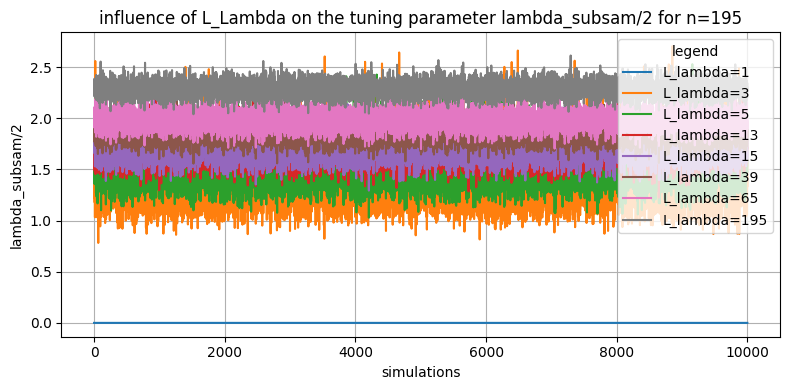

mean of lambda_subsam/2 for L_lambda=1 is: 0.0 .
mean of lambda_subsam/2 for L_lambda=3 is: 1.416043392533401 .
mean of lambda_subsam/2 for L_lambda=5 is: 1.5578496179461256 .
mean of lambda_subsam/2 for L_lambda=13 is: 1.7119911627572277 .
mean of lambda_subsam/2 for L_lambda=15 is: 1.729679586321185 .
mean of lambda_subsam/2 for L_lambda=39 is: 1.8729954263753388 .
mean of lambda_subsam/2 for L_lambda=65 is: 1.9802408814487849 .
mean of lambda_subsam/2 for L_lambda=195 is: 2.285292009354969 .
ok


In [51]:
#plots
selection_L_lambdas=L_lambdas[::] #only each second column is chosen for: [start : stop : step=2]
selection_lambdas_used=lambdas_used[:,::]
plot_time_series_sensitivity_analysis_L_lambda(selection_lambdas_used/2, selection_L_lambdas, number_of_observations=n,
                                               name_y_axis="lambda_subsam/2",
                                               title="influence of L_Lambda on the tuning parameter lambda_subsam/2",
                                               y_ticks_automatic=1, save_image=0, 
                                               name_of_copy="plot_lambdas_sensitive_L_lambda.png")
#means for table
for z in range(len(L_lambdas)):
    print(f'mean of lambda_subsam/2 for L_lambda={L_lambdas[z]} is: {np.mean((lambdas_used/2)[:,z])} .')


#selection_L_lambdas=L_lambdas[::3]
#selection_rank_prv=rank_prv[:,::3]
#plot_time_series_sensitivity_analysis_L_lambda(selection_rank_prv, selection_L_lambdas, number_of_observations=n,
                                               #name_y_axis="rank",
                                               #title="influence of L_Lambda on the rank of the PRV",
                                               #y_ticks_automatic=0, save_image=0,
                                               #name_of_copy="plot_rank_PRV_sensitive_L_lambda.png")

#selection_L_lambdas=L_lambdas[::3]
#selection_squared_2_norm_error_prv=squared_2_norm_error_prv[:,::3]
#plot_time_series_sensitivity_analysis_L_lambda(selection_squared_2_norm_error_prv, selection_L_lambdas,
                                               #number_of_observations=n, name_y_axis="error",
                                               #title="influence of L_Lambda on the squared Frobenius norm error of the PRV",
                                               #y_ticks_automatic=0, save_image=0,
                                               #name_of_copy="plot_error_PRV_sensitive_L_lambda.png")

#selection_L_lambdas=L_lambdas[::3]
#selection_denoised_squared_2_norm_error_prv=denoised_squared_2_norm_error_prv[:,::3]
#plot_time_series_sensitivity_analysis_L_lambda(selection_denoised_squared_2_norm_error_prv, selection_L_lambdas,
                                               #number_of_observations=n, name_y_axis="error",
                                               #title="influence of L_Lambda on the squared Frobenius norm denoised error of the PRV",
                                               #y_ticks_automatic=0, save_image=0,
                                               #name_of_copy="plot_error_denoised_PRV_sensitive_L_lambda.png")
                
print("ok")

In [52]:
#conclusion : 
#n=195:
#             lambda_subsam: n=78 and L=6 fits well to n=195 and L=15, where a bit more or less does not make a big difference.
#                            However, L=1 yields RV and L=n results in a large tuning parameter.
#consequence: 5<L<=39   is ok for n=195.

#n=390
#             lambda_subsam: n=78 and L=6 fits well to n=390 and L=30, where a bit more or less does not make a big difference.
#                            However, L=1 yields RV and L=n results in a large tuning parameter, maybe PRV=0...
#             rank_prv : L=1 has full rank as RV, other almost the same.
#             errors: all L besides 1 behave quite similar. Small L smaller errors.
#consequence: 13<L<=78   is ok for n=390, so also 6 for 78 relation almost.

In [53]:
#fast sensitivity analysis of the tuning parameter lambda

#setup
d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=2

Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, mu_dominant=10, std_dominant=0.2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5, std_normal=0.2,
                                             mu_vanishing=0.5, std_vanishing=0.2)

drift=np.random.randn(1,d)

number_of_simulations=10000 #10000 for factor = 5 runs in 2 min
                            #100 for factor = 300 runs in 1 min


lambda_prefactors=np.array([0, 0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75 , 1.9, 2, 10])
#monte carlo simulation
lambdas_used , rank_prv , squared_2_norm_error_prv , denoised_squared_2_norm_error_prv=fast_sensitivity_analysis_for_lambda_with_fixed_QV(
    Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
    lambda_prefactors=lambda_prefactors, L_lambda=L_lambda,
    number_of_simulations=number_of_simulations, number_error_types=2, progress_number=number_of_simulations/10)

print('ok')


0 simulations: finished.
1000 simulations: finished.
2000 simulations: finished.
3000 simulations: finished.
4000 simulations: finished.
5000 simulations: finished.
6000 simulations: finished.
7000 simulations: finished.
8000 simulations: finished.
9000 simulations: finished.
ok


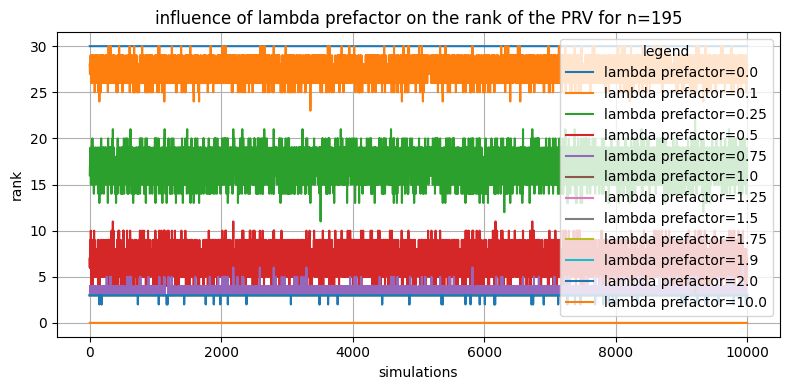

mean of rank for lambda prefactor=0.0 is: 30.0 .
mean of rank for lambda prefactor=0.1 is: 27.4438 .
mean of rank for lambda prefactor=0.25 is: 17.0789 .
mean of rank for lambda prefactor=0.5 is: 6.8344 .
mean of rank for lambda prefactor=0.75 is: 3.1574 .
mean of rank for lambda prefactor=1.0 is: 3.0001 .
mean of rank for lambda prefactor=1.25 is: 3.0 .
mean of rank for lambda prefactor=1.5 is: 3.0 .
mean of rank for lambda prefactor=1.75 is: 3.0 .
mean of rank for lambda prefactor=1.9 is: 2.9989 .
mean of rank for lambda prefactor=2.0 is: 2.995 .
mean of rank for lambda prefactor=10.0 is: 0.0 .
ok


In [54]:
#plots

#selection_lambda_prefactors=lambda_prefactors #only each second column is chosen: [start : stop : step=2]
#selection_lambdas_used=lambdas_used
#plot_time_series_sensitivity_analysis_lambda_prefactors(selection_lambdas_used/2, selection_lambda_prefactors,
                                                        #number_of_observations=n, name_y_axis="lambda_subsam/2",
                                                        #title="influence of lambda prefactor on the tuning parameter lambda_subsam/2",
                                                        #y_ticks_automatic=1, save_image=0,
                                                        #name_of_copy="plot_lambdas_sensitive_lambda.png")

selection_lambda_prefactors=lambda_prefactors #only each second column is chosen: [start : stop : step=2]
selection_rank_prv=rank_prv
plot_time_series_sensitivity_analysis_lambda_prefactors(selection_rank_prv, selection_lambda_prefactors, number_of_observations=n,
                                                name_y_axis="rank",title="influence of lambda prefactor on the rank of the PRV",
                                                y_ticks_automatic=1, save_image=0,
                                               name_of_copy="plot_rank_PRV_sensitive_lambda.png")
#means for table
for z in range(len(selection_lambda_prefactors)):
    print(f'mean of rank for lambda prefactor={selection_lambda_prefactors[z]} is: {np.mean((selection_rank_prv)[:,z])} .')



#selection_lambda_prefactors=lambda_prefactors[0:len(lambda_prefactors)-2] #only each second column is chosen: [start : stop : step=2]
#selection_squared_2_norm_error_prv=squared_2_norm_error_prv[0:len(lambda_prefactors)-2]
#plot_time_series_sensitivity_analysis_lambda_prefactors(selection_squared_2_norm_error_prv, selection_lambda_prefactors,
                                               #number_of_observations=n, name_y_axis="error",
                                               #title="influence of lambda prefactor on the squared Frobenius norm error of the PRV",
                                               #y_ticks_automatic=1, save_image=0,
                                               #name_of_copy="plot_error_PRV_sensitive_lambda.png")

#selection_lambda_prefactors=lambda_prefactors[0:len(lambda_prefactors)-2] #only each second column is chosen: [start : stop : step=2]
#selection_denoised_squared_2_norm_error_prv=denoised_squared_2_norm_error_prv[0:len(lambda_prefactors)-2]
#plot_time_series_sensitivity_analysis_lambda_prefactors(selection_denoised_squared_2_norm_error_prv, selection_lambda_prefactors,
                                               #number_of_observations=n,  name_y_axis="error",
                                               #title="influence of lambda prefactor on the squared Frobenius norm denoised error of the PRV",
                                               #y_ticks_automatic=1, save_image=0,
                                               #name_of_copy="plot_error_denoised_PRV_sensitive_lambda.png")
print("ok")

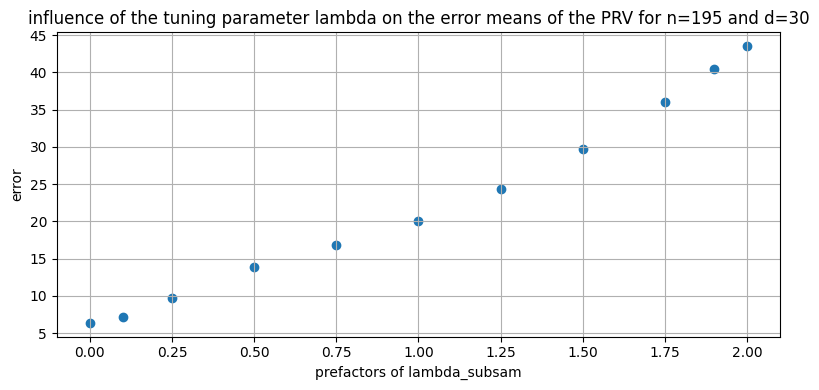

ok


In [55]:
#plot of mean error
selection_lambda_prefactors=lambda_prefactors[0:len(lambda_prefactors)-1] #only each second column is chosen: [start : stop : step=2]
selection_squared_2_norm_error_prv=squared_2_norm_error_prv[:,0:len(lambda_prefactors)-1]
plot_mean_of_errors_sensitivity_analysis_lambda_prefactors(selection_squared_2_norm_error_prv, selection_lambda_prefactors, number_of_observations=n,
                                                            name_y_axis="error" ,
                                                            title="influence of the tuning parameter lambda on the error means of the PRV",
                                                            y_ticks_automatic=1, save_image=0,
                                                            name_of_copy="scatter_plot_error_means_PRV_sensitive_lambda.png")

print("ok")

In [56]:
#conclusion: in the typical settings with n>d lambda is chosen to big in terms of the Frobenius error. 
#            Actually, rv good (maybe even best) choice.
#            But, if the rank is considered, penalization and PRV makes sense. If the rank is the goal, PRV works.

In [57]:
#######################################################################################
#now: Bias Variance Decomposition with best choice = PRV
#######################################################################################

In [69]:
#fast sensitivity analysis of the tuning parameter lambda

#setup
d=30*10 # high dimesnional setting with d > n , only 1 driving factor, others noise
n_standard=78
L_lambda_standard=6

factor=1  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=0

#attention: mu_vanishing=0 for better bias-var-decomposition
Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, mu_dominant=10, std_dominant=0.2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5, std_normal=0.2,
                                             mu_vanishing=0, std_vanishing=0.2)

drift=np.random.randn(1,d)

true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing
print("First 10 true eigenvalues of Sigma: ", true_eigenvalues_Sigma[0:10] )

print("ok")

First 10 true eigenvalues of Sigma:  [9.86828853 0.55657542 0.53618224 0.50528868 0.484501   0.47811616
 0.44185721 0.43867173 0.42849465 0.4267178 ]
ok


0 simulations: finished.
50 simulations: finished.
100 simulations: finished.
150 simulations: finished.
200 simulations: finished.
250 simulations: finished.
300 simulations: finished.
350 simulations: finished.
400 simulations: finished.
450 simulations: finished.
500 simulations: finished.
550 simulations: finished.
600 simulations: finished.
650 simulations: finished.
700 simulations: finished.
750 simulations: finished.
800 simulations: finished.
850 simulations: finished.
900 simulations: finished.
950 simulations: finished.


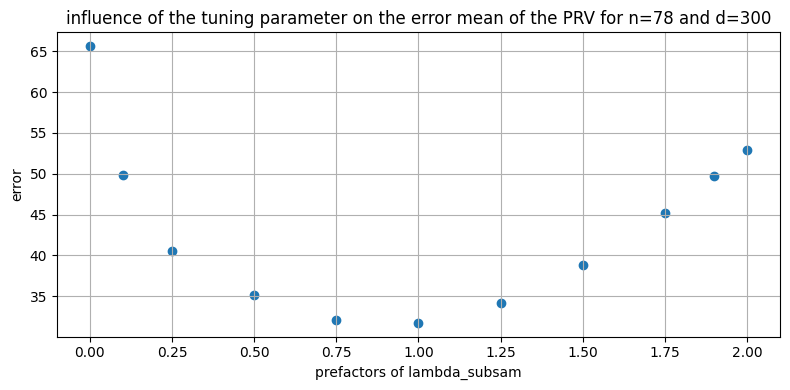

ok


In [72]:
#run takes around 10 min


number_of_simulations=1000 #1000 for factor = 1 and d=300 runs in 10 min
                        #100 for factor = 1 and d=300 runs 1 min


lambda_prefactors=np.array([0, 0.1, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75 , 1.9, 2])

#monte carlo simulation
lambdas_used , rank_prv , squared_2_norm_error_prv , denoised_squared_2_norm_error_prv=fast_sensitivity_analysis_for_lambda_with_fixed_QV(
    Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
    lambda_prefactors=lambda_prefactors, L_lambda=L_lambda,
    number_of_simulations=number_of_simulations, number_error_types=2, progress_number=number_of_simulations/20)

#plot

selection_lambda_prefactors_bvd=lambda_prefactors[0:len(lambda_prefactors)-0] #only each second column is chosen: [start : stop : step=2]
selection_squared_2_norm_error_prv_bvd=squared_2_norm_error_prv[:,0:len(lambda_prefactors)-0]
plot_mean_of_errors_sensitivity_analysis_lambda_prefactors(selection_squared_2_norm_error_prv_bvd, selection_lambda_prefactors_bvd, number_of_observations=n,
                                                            dimension=d, name_y_axis="error" ,
                                                            title="influence of the tuning parameter on the error mean of the PRV",
                                                            y_ticks_automatic=1, save_image=1,
                                                            name_of_copy="bias_variance_decomposition_scatter_plot_error_means_PRV_sensitive_lambda.png")
print('ok')


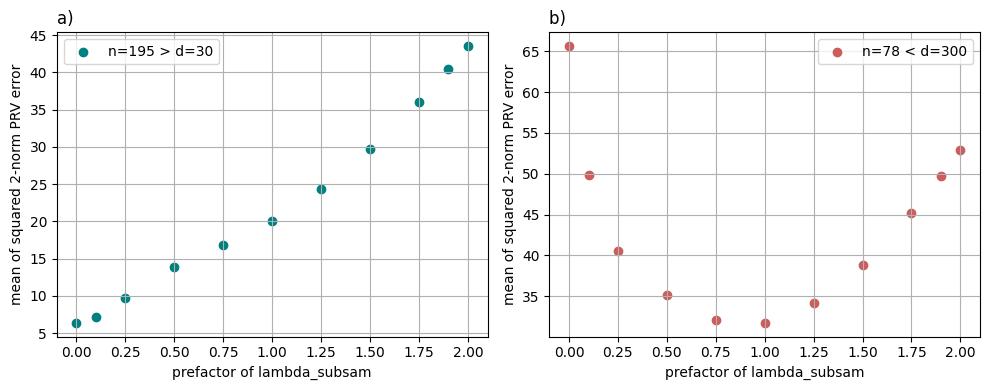

in b) , the optimal tuning is with a prefactor in between 0.75 and 1.25 -> lambda_subsam is a good choice
ok


In [74]:
#plot for thesis

#squared Frobenius norm errors for different prefactors of the tuning parameter lambda

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4)) #(10,4) is good  , (8,4) is ok

#a) d=30, n=195
x=selection_lambda_prefactors
y1=np.mean(selection_squared_2_norm_error_prv, axis=0)

ax1.scatter(x, y1, label="n=195 > d=30", color="teal")

ax1.set_xlabel("prefactor of lambda_subsam")
ax1.set_ylabel("mean of squared 2-norm PRV error")
ax1.set_title("a) ", loc="left")
ax1.legend()
ax1.grid(True)


#b) d=300, n=78

x=selection_lambda_prefactors_bvd
y2=np.mean(selection_squared_2_norm_error_prv_bvd, axis=0)

ax2.scatter(x, y2, label="n=78 < d=300", color="indianred")

ax2.set_xlabel("prefactor of lambda_subsam")
ax2.set_ylabel("mean of squared 2-norm PRV error")
ax2.set_title("b) ", loc="left")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

fig.savefig("constant_vola_prefactors_lambda_bias_var_decomposition.png", dpi=300, bbox_inches="tight")
        #high resolution dpi, cut of edge bbox
plt.close()

print("in b) , the optimal tuning is with a prefactor in between 0.75 and 1.25 -> lambda_subsam is a good choice")

print("ok")

In [75]:
#######################################################################################
#now: simulation of theoretical findings
#######################################################################################

In [76]:
#validation tests for the theoretical lambdas

#setup
d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)


delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=2

Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, mu_dominant=10, std_dominant=0.5,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5, std_normal=0.5,
                                             mu_vanishing=0, std_vanishing=0.2)

true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing

drift=np.random.randn(1,d) 

#parameters
gamma= 82*10**(6)
v_mu=np.linalg.norm(drift)**2
v_c_2=np.trace(Sigma)
v_c_2_old=np.linalg.norm(sqrtm(Sigma), 'fro')**2   # 'fro' is Frobenius norm
v_c_inf=np.linalg.norm(Sigma, 2)   # 2 is spectral norm
#print(v_c_2_old, v_c_2)
#-> v_c_2 works with old and new formula.
print("need to divide v_mu by 10 to ensure v_c_inf > v_mu:")
print("v_c_inf, v_mu:",v_c_inf, v_mu)
d=Sigma.shape[0]
sampling_interval=delta_n


#lambda_esterr
tau=np.log(6*d)

print("lambda_esterr, max. term position=", 
      lambda_esterr_calculation(Sigma=Sigma, drift=drift, sampling_interval=delta_n, tau=np.log(6*d), gamma= 82*10**(6)))


#'''
print("terms in th max: ",20*(v_c_2*v_mu*sampling_interval)/v_c_inf, 20*(v_c_2*v_mu*sampling_interval)**0.5,
                     ((4*gamma*(tau+np.log(6*d)))*(v_c_2*v_c_inf*sampling_interval))**0.5,
                     (2*gamma/2255)*(tau+np.log(6*d))*v_c_2*sampling_interval)
#'''
#-> index return works



#lambda_conint
alpha=0.05

print("lambda_conint, max. term position=", 
      lambda_conint_calculation(Sigma=Sigma, drift=drift, sampling_interval=delta_n, alpha=0.05, gamma= 82*10**(6)))

#'''
print("terms in the max: ",20*(v_c_2*v_mu*sampling_interval)**0.5,
                     ((4*gamma*np.log(6*d/alpha))*(v_c_2*v_c_inf*sampling_interval))**0.5,
                      20*(v_c_2*v_mu*sampling_interval)/v_c_inf,
                     (2*gamma/2255)*np.log(6*d/alpha)*v_c_2*sampling_interval)
#'''
#->index return works

#dominant terms decomposed:
#print((2*gamma/2255),(tau+np.log(6*d)), v_c_2, sampling_interval)
#(2*gamma/2255)>72727 is dominant!!!
#print((2*gamma/2255),(np.log(6*d/alpha)), v_c_2, sampling_interval)
#(2*gamma/2255)>72727 is dominant!!!

#old:
#print(4*gamma, np.log(6*d/alpha), v_c_2*v_c_inf, sampling_interval)
#4*gamma dominant

print("consequence of very large gamnma: condition (4.151) not fulfilled:")
print("need:", 1/delta_n,">", (2*gamma/2255**2)*np.log(6*d)*v_c_2/v_c_inf )
#need to fulfill: n>195*2.24

print("=>problem: gamma to large and n to small, hence lambdas very large")



print('ok')

need to divide v_mu by 10 to ensure v_c_inf > v_mu:
v_c_inf, v_mu: 10.629601937340654 29.83950847046024
lambda_esterr, max. term position= (95100.49720327501, 3)
terms in th max:  7.068795789636907 38.76557375305825 67520.89110939 95100.49720327501
lambda_conint, max. term position= (74981.21297158439, 3)
terms in the max:  38.76557375305825 59954.66799564272 7.068795789636907 74981.21297158439
consequence of very large gamnma: condition (4.151) not fulfilled:
need: 195.0 > 386.8333028515542
=>problem: gamma to large and n to small, hence lambdas very large
ok


In [78]:
#illustration of theory via monte carlo simulations

#setup
d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=2

#needed to fulfill condition (4.137) of Theorem 4.8
size_correction_v_c_2=10**(-3)


Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, 
                                             mu_dominant=10*size_correction_v_c_2, std_dominant=0.2*size_correction_v_c_2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5*size_correction_v_c_2, 
                                             std_normal=0.2*size_correction_v_c_2,
                                             mu_vanishing=0.5*size_correction_v_c_2, std_vanishing=0.2*size_correction_v_c_2)

true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing

drift=np.random.randn(1,d)*size_correction_v_c_2

number_of_simulations=10000 #10000 for factor = 5 runs in 2 min
                            #100 for factor = 300 runs in 1 min


#lambdas
gamma= 82*10**(6)  # normal: 82*10**(6)
tau=np.log(6*d)
alpha=0.05

#is n big enough?
print(f'n={n} fulfills condition (4.137) of Theorem 4.8 if: n > 870*v_c_2={870*np.trace(Sigma)}')
print("ensured by multiplying all eigenvalue means and standard deviations with size_correction_v_c_2: ",size_correction_v_c_2 )
#

#monte carlo simulation

(lambdas_subsam_used, lambda_esterr, index_of_maximal_value_esterr, lambda_conint, index_of_maximal_value_conint,
 eigenvalues_rv , eigenvalues_prv_subsam , eigenvalues_prv_esterr , eigenvalues_prv_conint ,
 rank_rv , rank_prv , all_errors)=monte_carlo_simulation_for_theory(Sigma, Sigma_denoised,
                                                                    sampling_interval=delta_n, drift=drift, tau=tau, L_lambda=L_lambda,
                                                                    alpha=alpha, gamma= gamma,
                                                                    number_of_simulations=number_of_simulations,
                                                                    number_error_types=12,
                                                                    progress_number=number_of_simulations/10)
fro_norm=np.linalg.norm(Sigma, 'fro')**2
print(f'Frobenius norm of Sigma: {np.sqrt(fro_norm)} .')


print('ok')

n=195 fulfills condition (4.137) of Theorem 4.8 if: n > 870*v_c_2=30.215918605163278
ensured by multiplying all eigenvalue means and standard deviations with size_correction_v_c_2:  0.001
0 simulations: finished.
1000 simulations: finished.
2000 simulations: finished.
3000 simulations: finished.
4000 simulations: finished.
5000 simulations: finished.
6000 simulations: finished.
7000 simulations: finished.
8000 simulations: finished.
9000 simulations: finished.
Frobenius norm of Sigma: 0.01276445502583048 .
ok


lambda_esterr, max. term position= (134.5314891314191, 3)
lambda_conint, max. term position= (106.07025761795855, 3)


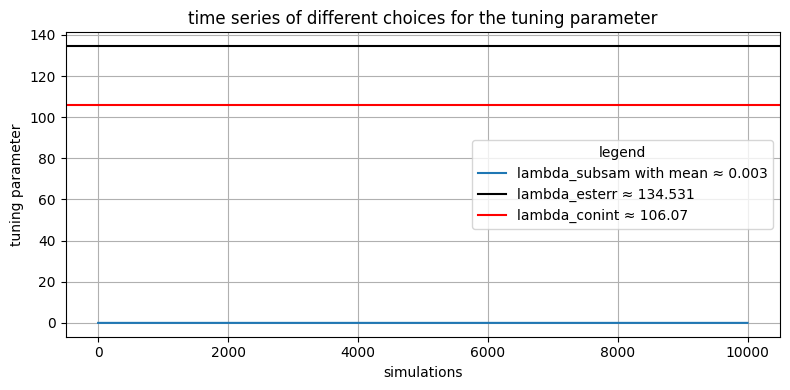

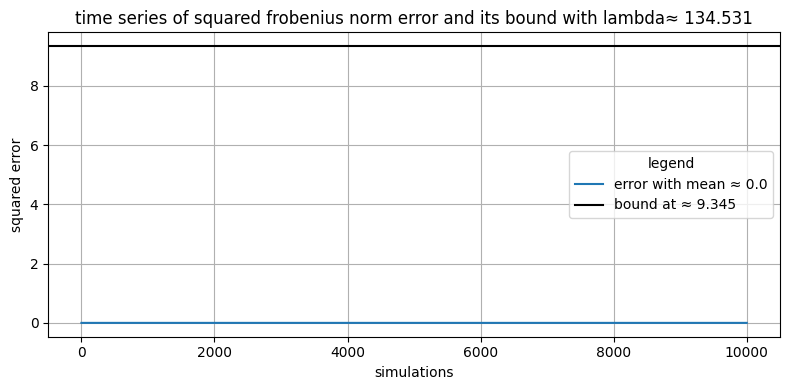

first argument in minimum of the bound is: 2*134.5314891314191*0.03473094092547503 .
second argument in minimum of the bound is: 3*134.5314891314191^2*30 .
the first squared frobenius_errors are: [0.00016293 0.00016293 0.00016293 0.00016293 0.00016293]
Squared Frobenius norm of Sigma: 0.00016293131210644898 . 
Hence, the PRV estimators are zero (tuning parameter lambda_esterr/2>norm of Sigma>ev of Sigma).


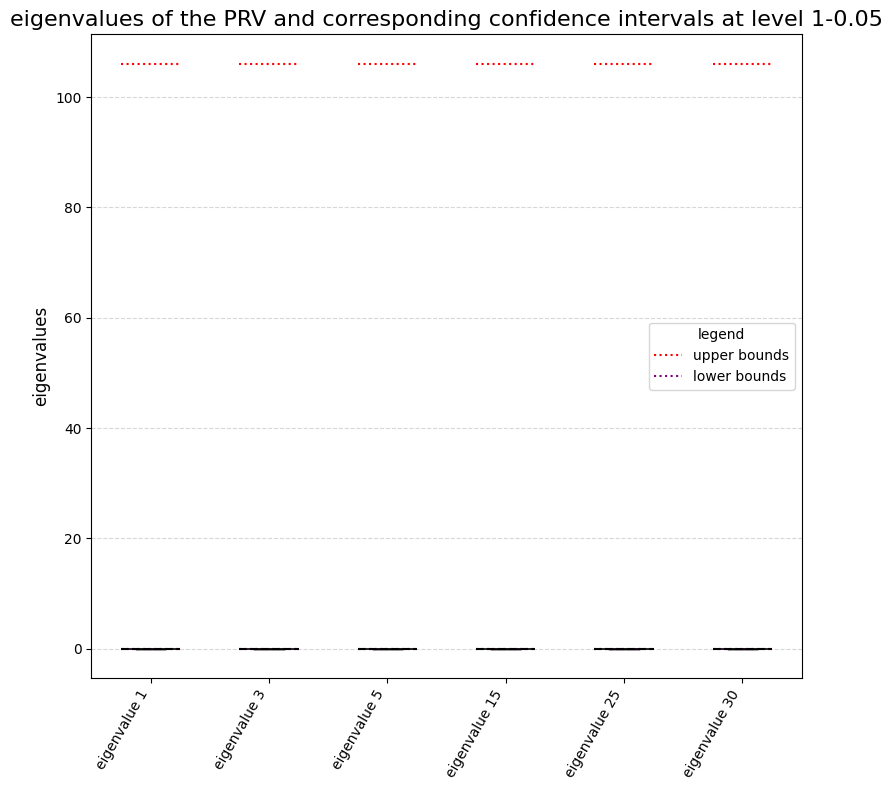

here the intervals for ev of Sigma are translated in intervals for PRV (see argumentation in the thesis in Section 6.2)
lambda_conint=106.07025761795855
Since half of this is larger than the norm of Sigma, the PRV and its eigenvalues vanish.
ok


In [86]:
#plots

print("lambda_esterr, max. term position=", 
      lambda_esterr_calculation(Sigma=Sigma, drift=drift, sampling_interval=delta_n, tau=np.log(6*d), gamma= 82*10**(6)))
print("lambda_conint, max. term position=", 
      lambda_conint_calculation(Sigma=Sigma, drift=drift, sampling_interval=delta_n, alpha=0.05, gamma= 82*10**(6)))

#different lambdas
plot_lambda_choices(lambdas_subsam_used, lambda_esterr, lambda_conint,
                        title="time series of different choices for the tuning parameter",
                                                      save_image=0,
                                                      name_of_copy="plot_different_lambda_choices.png")

#squared Frobenius norm error and its bound from Theorem 4.8
bound_theorem_4_8=min(2*lambda_esterr*np.linalg.norm(Sigma, 'nuc'), 3*lambda_esterr**(2)*np.linalg.matrix_rank(Sigma))
plot_bound_of_squared_frobenius_error_theorem_4_8(squared_frobenius_errors=all_errors[:,2],
                                                  bound=bound_theorem_4_8, lambda_esterr=lambda_esterr,
                                                  title="time series of squared frobenius norm error and its bound",
                                                  save_image=0,
                                                  name_of_copy="plot_error_bound_theorem_4_8.png")
nuc_norm=np.linalg.norm(Sigma, 'nuc')
rank_sigma=np.linalg.matrix_rank(Sigma)
print(f'first argument in minimum of the bound is: 2*{lambda_esterr}*{nuc_norm} .')
print(f'second argument in minimum of the bound is: 3*{lambda_esterr}^2*{rank_sigma} .')
print("the first squared frobenius_errors are:",all_errors[0:5:,2])
print(f'Squared Frobenius norm of Sigma: {fro_norm} . \nHence, the PRV estimators are zero (tuning parameter lambda_esterr/2>norm of Sigma>ev of Sigma).')



#confidence for the eigenvalues of the PRV
indices_of_plotted_eigenvalues=np.array([1,3,5,15,25,d])
#prv with lambda_conint
boxplot_eigenvalues_confidence(eigenvalues_prv=eigenvalues_prv_conint, indices_of_plotted_eigenvalues=indices_of_plotted_eigenvalues,
                               Sigma=Sigma, lambda_used=lambda_conint,
                               title=f'eigenvalues of the PRV and corresponding confidence intervals at level 1-{alpha}',
                               save_image=0,
                               name_of_copy="plot_eigenvalues_confidence_theorem_5_3.png")

print("here the intervals for ev of Sigma are translated in intervals for PRV (see argumentation in the thesis in Section 6.2)")
print(f'lambda_conint={lambda_conint}')
print("Since half of this is larger than the norm of Sigma, the PRV and its eigenvalues vanish.")
'''
#prv with lambda_subsam
boxplot_eigenvalues_confidence(eigenvalues_prv=eigenvalues_prv_subsam, indices_of_plotted_eigenvalues=indices_of_plotted_eigenvalues,
                               Sigma=Sigma, lambda_used=np.mean(lambdas_subsam_used),
                               title=f'eigenvalues of the PRV and corresponding confidence intervals at level 1-{alpha}',
                               save_image=0,
                               name_of_copy="plot_eigenvalues_confidence_theorem_5_3.png")
                               
'''

print('ok')

In [88]:
#summary:
#bounds are correct, but really not sharp!
#since for larger n the rv becomes better and better, 
#even then an application of the error bounds might not be sharp in the constant volatility case

#is delta_n small enough? yes, 870 v_c_2=870*np.linalg.norm(Sigma, 'fro')**2
#-> smaller size of Sigma with size_correction_v_c_2=10**(-3) was performed



In [89]:
#####################################################################################
#comparison with Th 4.7 (key result annd origin of the large  gamma)
#####################################################################################

In [90]:
#illustration of theory via monte carlo simulations

#setup
d=30
n_standard=78
L_lambda_standard=6

factor=5/2  #1=paper Christensen, high implies smaller sampling interval and more subsamples
            #5/2=1 price per 2 mins (see empirical application)
            #5=1 price per minute (normal)
            #300 = 1 price per s (maximal)
n=int(n_standard*factor)
L_lambda=int(L_lambda_standard*factor)

delta_n=1/n

dominant_eigenvalues=1
normal_eigenvalues=2

#needed to fulfill condition (4.137) of Theorem 4.8
size_correction_v_c_2=10**(-3)


Sigma , Sigma_denoised =special_qv_generator(d=d, dominant_eigenvalues=dominant_eigenvalues, 
                                             mu_dominant=10*size_correction_v_c_2, std_dominant=0.2*size_correction_v_c_2,
                                             normal_eigenvalues=normal_eigenvalues, mu_normal=5*size_correction_v_c_2, 
                                             std_normal=0.2*size_correction_v_c_2,
                                             mu_vanishing=0.5*size_correction_v_c_2, std_vanishing=0.2*size_correction_v_c_2)

true_eigenvalues_Sigma= np.sort(np.linalg.eigh(Sigma)[0])[::-1] #sort creates increasing, now decreasing

drift=np.random.randn(1,d)*size_correction_v_c_2

number_of_simulations=10000 #10000 for factor = 5 runs in 2 min
                            #100 for factor = 300 runs in 1 min


#lambdas
gamma= 82*10**(6)  # normal: 82*10**(6)
tau=np.log(6*d)
alpha=0.05

#is n big enough?
print(f'n={n} fulfills condition (4.137) of Theorem 4.8 if: n > 870*v_c_2={870*np.trace(Sigma)}')
print("ensured by multiplying all eigenvalue means and standard deviations with size_correction_v_c_2: ",size_correction_v_c_2 )
#


#monte carlo simulation
eigenvalues_rv , eigenvalues_prv , lambdas_used , rank_rv , rank_prv , all_errors=fast_monte_carlo_simulation_with_fixed_QV(
    Sigma_true=Sigma, Sigma_true_denoised=Sigma_denoised, sampling_interval=delta_n, drift=drift,
    L_lambda=L_lambda, number_of_simulations=number_of_simulations, number_error_types=12,
    progress_number=number_of_simulations/10)

spectral_norm_error_rv=all_errors[:,5]

print('ok')

n=195 fulfills condition (4.137) of Theorem 4.8 if: n > 870*v_c_2=28.710376826358377
ensured by multiplying all eigenvalue means and standard deviations with size_correction_v_c_2:  0.001
0 simulations: finished.
1000 simulations: finished.
2000 simulations: finished.
3000 simulations: finished.
4000 simulations: finished.
5000 simulations: finished.
6000 simulations: finished.
7000 simulations: finished.
8000 simulations: finished.
9000 simulations: finished.
ok


x_min=  0.013075945134364456  , terms in max are:  5.184786442706341e-07 0.0013075945134364455 5.1811544552750144e-05
maximal rv error:  0.004857273754087074
-> problem, x_min is too large, as n is too small, hence all interesting x are too small to apply Theorem 4.7 for them.


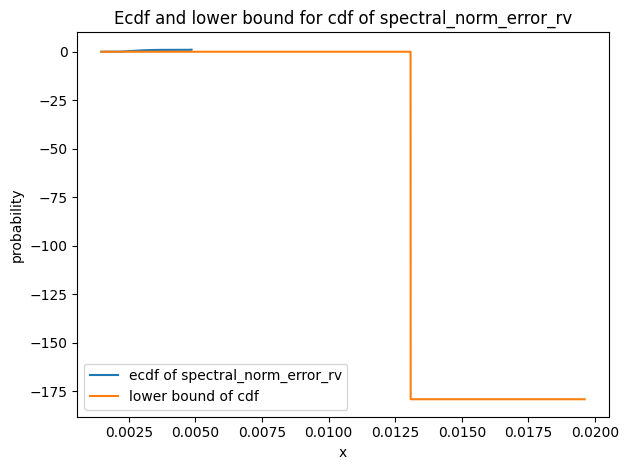

ok


In [92]:
#plot:


#ecdf
spectral_norm_error_rv_sorted = np.sort(spectral_norm_error_rv)
ecdf = np.arange(1, number_of_simulations + 1) / number_of_simulations


#plot for Th 4.7 bounds
gamma=82*10**(6)
v_mu=np.linalg.norm(drift)**2
v_c_2=np.linalg.norm(sqrtm(Sigma), 'fro')**2
v_c_inf=np.linalg.norm(Sigma, 2)
d=Sigma.shape[0]

def concentration_inequality_rv(x, d, v_mu, v_c_2, v_c_inf, delta_n, gamma):

    y=1-6*d*np.exp(((-1)*x/(gamma*v_c_2*v_c_inf*delta_n))* np.minimum(x, 2255*v_c_inf))

    x_min=10*max((v_c_2*v_mu*delta_n)/v_c_inf,(v_c_2*v_c_inf*delta_n)**0.5, v_c_inf*delta_n)
    y[x<x_min]=0  #inequality in Th 4.7 yields lower bound of distribution function: trivial lower bound = 0
    return np.array(y)

x_min=10*max((v_c_2*v_mu*delta_n)/v_c_inf,(v_c_2*v_c_inf*delta_n)**0.5, v_c_inf*delta_n)

print("x_min= ",x_min," , terms in max are: ", (v_c_2*v_mu*delta_n)/v_c_inf,(v_c_2*v_c_inf*delta_n)**0.5, v_c_inf*delta_n)
print("maximal rv error: ", np.max(spectral_norm_error_rv))
print("-> problem, x_min is too large, as n is too small, hence all interesting x are too small to apply Theorem 4.7 for them.") 

x=np.linspace(min(np.min(spectral_norm_error_rv), x_min), max(np.max(spectral_norm_error_rv),1.5*x_min),
              max(100,5*number_of_simulations)) #at least 100 data points evenly spaced in interval
dist_bounds_concentration_inequality_rv=concentration_inequality_rv(x, d, v_mu, v_c_2, v_c_inf, delta_n, gamma)
#print(x, dist_bounds_concentration_inequality_rv)



#plot
plt.figure()
plt.step(spectral_norm_error_rv_sorted, ecdf, where="post", label = "ecdf of spectral_norm_error_rv")
#post means: ecdf[i] is taken in [spectral_norm_error_rv_sorted[i], spectral_norm_error_rv_sorted[i+1])
plt.plot(x, dist_bounds_concentration_inequality_rv, label="lower bound of cdf")

plt.xlabel("x")
plt.ylabel("probability")



plt.title("Ecdf and lower bound for cdf of spectral_norm_error_rv")


plt.legend()
plt.tight_layout()
plt.show()

print("ok")

n=195, needs > 28.710376826358377, x_min=0.013075945134364456


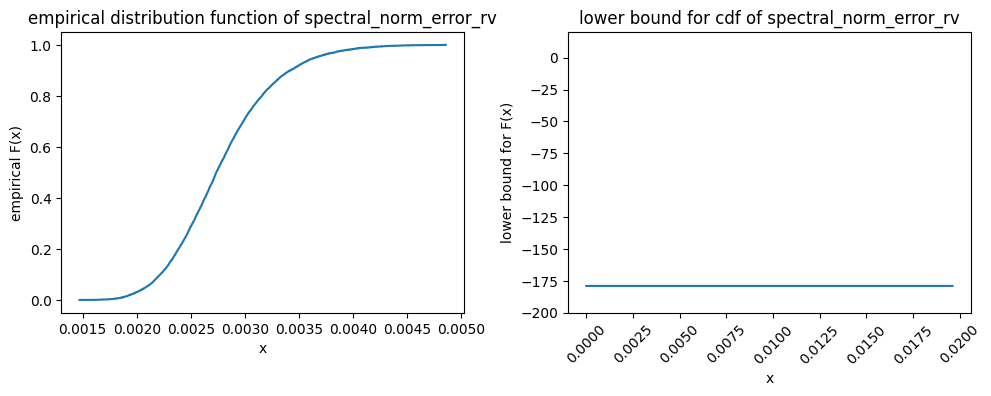

lower bounds min=  -179.0 = 1-6*30*1, lower bounds max=  -178.99950609823858
ok


In [93]:
#plot

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

#ecdf
spectral_norm_error_rv_sorted = np.sort(spectral_norm_error_rv)
ecdf = np.arange(1, number_of_simulations + 1) / number_of_simulations

axes[0].step(spectral_norm_error_rv_sorted, ecdf, where="post")
#post means: ecdf[i] is taken in [spectral_norm_error_rv_sorted[i], spectral_norm_error_rv_sorted[i+1])
axes[0].set_xlabel("x")
axes[0].set_ylabel("empirical F(x)")
axes[0].set_title("empirical distribution function of spectral_norm_error_rv")


def concentration_inequality_rv_extension(x, d, v_mu, v_c_2, v_c_inf, delta_n, gamma):

    y=1-6*d*np.exp(((-1)*x/(gamma*v_c_2*v_c_inf*delta_n))* np.minimum(x, 2255*v_c_inf))
    #extension does not control if x larger than x_min
    #x_min=10*max((v_c_2*v_mu*delta_n)/v_c_inf,(v_c_2*v_c_inf*delta_n)**0.5, v_c_inf*delta_n)
    #y[x<x_min]=0  #inequality in Th 4.7 yields lower bound of distribution function
    return np.array(y)


x_min=10*max((v_c_2*v_mu*delta_n)/v_c_inf,(v_c_2*v_c_inf*delta_n)**0.5, v_c_inf*delta_n)
x=np.linspace(min(np.min(spectral_norm_error_rv), x_min,0), max(np.max(spectral_norm_error_rv),1.5*x_min),
              max(100,5*number_of_simulations)) #at least 100 data points evenly spaced in interval
dist_bounds_concentration_inequality_rv=concentration_inequality_rv_extension(x, d, v_mu, v_c_2, v_c_inf, delta_n, gamma)
#print(x, dist_bounds_concentration_inequality_rv)

axes[1].plot(x, dist_bounds_concentration_inequality_rv)
axes[1].set_xlabel("x")
axes[1].set_ylabel("lower bound for F(x)")
axes[1].set_title("lower bound for cdf of spectral_norm_error_rv")
axes[1].set_ylim(-200, 20)
axes[1].tick_params(axis='x', rotation=45)


print(f'n={n}, needs > {870*v_c_2}, x_min={x_min}')

plt.tight_layout()
plt.show()

print("lower bounds min= ",np.min(dist_bounds_concentration_inequality_rv) , 
      "= 1-6*30*1, lower bounds max= ", np.max(dist_bounds_concentration_inequality_rv))

print("ok")

In [94]:
#-> Theorem 4.7 yields only trivial/upper lower bounds (probability<=1 or >=0)

In [95]:
#######################################################################################
#now: testing
#######################################################################################

In [96]:
#ask for information about object or function
#?fast_realized_variance
#?all_errors
#?penalized_realized_variance_for_given_lambda_and_RV
#?fast_sensitivity_analysis_for_lambda_with_fixed_QV
#?monte_carlo_simulation_for_theory

#squared_2_norm_error_rv , squared_2_norm_error_prv , 1_norm_error_rv , 1_norm_error_prv ,
#spectral_norm_error_rv , spectral_norm_error_prv ,
#denoised_squared_2_norm_error_rv , denoised_squared_2_norm_error_prv ,
#denoised_1_norm_error_rv , denoised_1_norm_error_prv , denoised_spectral_norm_error_rv , spectral_norm_error_prv